In [18]:
import numpy as np
import pandas as pd
import timecorr as tc
import hypertools as hyp
import supereeg as se
from matplotlib import pyplot as plt
from matplotlib import animation as ani
import seaborn as sns
import os
from glob import glob as lsdir
from scipy.io import loadmat as load
import numba
import nltools as nlt
import nilearn as nl
import nibabel as nib
from nilearn.input_data import NiftiMasker
from scipy.spatial.distance import pdist, cdist, squareform
from collections import deque
from IPython.display import HTML
import matlabengine as mlab
import matlab

%matplotlib inline

ModuleNotFoundError: No module named 'matlabengine'

In [ ]:
# Q: ls in nii_files, regressor_files will return an empty list so how to access data? 
# Q: cluster masks don't exist either? 

datadir = os.path.join(os.getenv('HOME'), 'data', 'fMRI', 'dffr')
datadir = os.path.join("C:\Users\mgnli\OneDrive - Dartmouth College\Documents\data-cdl")
nii_files = lsdir(os.path.join(datadir, '*.nii.gz'))
regressor_files = lsdir(os.path.join(datadir, 'regmats', '*.mat'))
#cluster_masks = os.path.join('clusters', 'k50_2mm_gm_split_cleaned.nii.gz')
#cluster_masks = os.path.join('clusters', 'Schaefer2018_1000Parcels_17Networks_order_FSLMNI152_2mm.nii.gz')
cluster_masks = os.path.join('clusters', 'Schaefer2018_100Parcels_17Networks_order_FSLMNI152_2mm.nii.gz')
## kernel_weights = tc.gaussian_weights
kernel_params = {'var': 10}

figdir = os.path.join('figs', 'gaussian', 'var10', 'Schaefer', '100_parcels')
if not os.path.exists(figdir):
    os.makedirs(figdir)

None data fMRI dffr


NameError: name 'datadir' is not defined

In [ ]:
# Q: how is data/mask stored? 
# [a, b, c, d]
# where a = , b = , c = , d = 

# T = d 
# K = 
# Y = masked data 

def apply_mask(data, mask):
    data = data.get_data()
    mask = mask.get_data()

    # print("data shape: ", data.shape)
    # print("mask shape: ", mask.shape)

    separated = (np.ndim(mask) > 3)
    
    T = data.shape[3]
    
    if separated:
        K = mask.shape[3]
    else:
        labels = np.unique(mask)
        labels = labels[labels > 0] # what is labels?
        K = len(labels)
    Y = np.zeros([T, K])
    
    for k in np.arange(K):
        if separated:
            roi_mask = mask[:, :, :, k]
            roi_inds = np.where(roi_mask) # confused 
        else:
            roi_inds = np.where(mask == labels[k])
        Y[:, k] = np.mean(data[roi_inds[0], roi_inds[1], roi_inds[2], :], axis=0)
    return Y

In [ ]:
def get_cluster_centers(mask, node_color='k', node_size=10, plot_it=True, **kwargs):
    mask_bo = se.Brain(mask, filter=None)
    data = mask_bo.data
    locs = mask_bo.locs
    
    separated = (data.shape[0] > 1)
    if separated:
        K = data.shape[0]
    else:
        labels = np.unique(data)
        labels = labels[labels > 0]
        K = len(labels)
    
    centers = np.zeros([K, locs.shape[1]])
    widths = np.zeros([K, 1])
    
    for k in np.arange(K):
        if separated:
            inds = np.where(data.iloc[k, :] == 1)[0]
        else:
            inds = np.where(data.iloc[0, :] == labels[k])[0]
        centers[k, :] = locs.iloc[inds, :].mean(axis=0)
        widths[k] = np.sqrt(((locs.iloc[inds, :] - centers[k, :]) ** 2).sum(axis=1)).mean(axis=0)
    
    if plot_it:
        nl.plotting.plot_connectome(np.eye(centers.shape[0]), centers, node_color=node_color, node_size=(widths ** 2) / 10, **kwargs)
    
    return centers, widths

In [ ]:
mask = nib.load(cluster_masks)
centers, widths = get_cluster_centers(mask)

NameError: name 'cluster_masks' is not defined

In [ ]:
def package_data(masked_data, nii_files, regressor_files):
    nii_subjs = list(map(lambda f: f.split('/')[-1][:-len('.nii')], nii_files))
    reg_subjs = list(map(lambda f: f.split('/')[-1][:-len('_regs_results.mat')], regressor_files))
    
    data = []
    for i, s in enumerate(nii_subjs):
        try:
            j = np.ravel(np.where(np.array(list(map(lambda x: x == s, reg_subjs)))))[0]
            print(f'matching {s} with {regressor_files[j]}')
            regmat = load(regressor_files[j])
            data.append({'data': masked_data[i], 'regmat': regmat['all_regressors'], 'mvpa': regmat['results']})
        except:
            print(f'missing data for {s}')
    return data

In [ ]:
data_fname = os.path.join('data', f'preprocessed_{cluster_masks.split(os.path.sep)[1][:-len(".nii.gz")]}.npz')
if os.path.exists(data_fname):
    print('loading preprocessed data from disk...')
    data = np.load(data_fname)['data']
else:
    print('preprocessing data...')
    masked_data = list(map(lambda f: apply_mask(nib.load(f), mask), nii_files))
    data = package_data(masked_data, nii_files, regressor_files)
    np.savez(data_fname, data=data)

NameError: name 'cluster_masks' is not defined

In [ ]:
regressors_key = ['Present list A', 
                  'Present list B (R)', 
                  'Present list B (F)',
                  'Recall list A (R)',
                  'Recall list B (R)', 
                  'Recall list A (F)',
                  'Recall list B (F)',
                  'Present localizer list 1',
                  'Recall localizer list 1',
                  'Present localizer list 2',
                  'Recall localizer list 2',
                  'Present scene localizer image',
                  'Present objects localizer image',
                  'Present scrambled scene localizer image']
present_a = [0]
present_b = [1, 2]
forget = [2, 5, 6]
remember = [1, 3, 4]

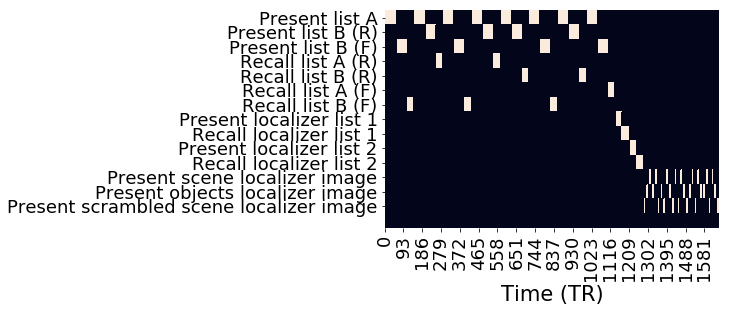

In [ ]:
#experiment labels from participant 0
h = sns.heatmap(data[0]['regmat'], cbar=False)
h.set_yticks(np.arange(len(regressors_key)) + 0.5)
h.set_yticklabels(regressors_key)
plt.yticks(rotation=0);
plt.xlabel('Time (TR)');

In [ ]:
def get_keys(inds):
    keys = []
    for i in inds:
        keys.append(regressors_key[i])
    return keys

In [ ]:
print(get_keys(present_a))
print(get_keys(present_b))
print(get_keys(remember))
print(get_keys(forget))

['Present list A']
['Present list B (R)', 'Present list B (F)']
['Present list B (R)', 'Recall list A (R)', 'Recall list B (R)']
['Present list B (F)', 'Recall list A (F)', 'Recall list B (F)']


In [ ]:
def get_bounds(x): #x is a line from a regressors matrix
    diffs = np.diff(np.array(x, dtype=np.float)) #strange things happen when x is an array of ints
    return np.where(diffs == 1)[0], np.where(diffs == -1)[0] #event starts, ends

In [ ]:
def get_events(data, event_times, before=25, after=25):
    '''
    return the data, centered on each event_time. the resulting matrix is of shape
    (before + after + 1) by data.shape[1] by len(event_times).  if an event starts
    or ends too close to the beginning or end of the given data, the slice of that
    event's representation in the result will contain nans to reflect the missing
    data.
    '''
    
    x = np.multiply(np.nan, np.zeros([before + after + 1, data.shape[1], len(event_times)]))
    for i, t in enumerate(event_times):
        start_time = t - before - 1
        end_time = t + after
        
        if start_time >= 0:
            start_ind = 0
        else:
            start_ind = np.abs(start_time)
            start_time = 0
        
        if end_time <= data.shape[0]:
            end_ind = before + after + 1
        else:
            end_ind = end_time - data.shape[0]
            end_time = data.shape[0]
        
        x[start_ind:end_ind, :, i] = data[start_time:end_time, :]
    return x

In [ ]:
def get_network_dynamics(x, rows, offset=0, before=50, after=50, **kwargs):
    def copier(a):
        if type(a) == list:
            return list(map(copier, a))
        return np.copy(a)
    
    if not (type(rows) == list):
        rows = [rows]
        delist = True
    else:
        delist = False
    
    nets = []
    for r in rows:
        next_data = list(map(lambda y: get_events(y['data'], get_bounds(y['regmat'][r, :])[0] + offset, before=before, after=after), x))
        next_means = list(map(lambda y: np.nanmean(y, axis=2), next_data))
        nets.append(tc.timecorr(copier(next_means), **kwargs))        
    if delist:
        return nets[0]
    else:
        return nets

In [ ]:
# credit: https://stackoverflow.com/questions/47004506/check-if-a-numpy-array-is-sorted
@numba.jit
def is_sorted(a):
    for i in range(a.size-1):
         if a[i+1] < a[i] :
               return False
    return True

In [ ]:
def ribbon(x, y, lb, ub=None, color='k', alpha=0.5):
    #assert is_sorted(x), 'x-coordinates must be monotonically increasing'
    
    if ub is None:
        ub = lb
    h1 = plt.fill_between(x, y-lb, y+ub, color=color, alpha=alpha)
    h2 = plt.plot(x, y, color=color)
    return h1, h2

In [ ]:
def event_ribbon(x, ts=None, limit_t=None, color='k', alpha=0.5):
    if ts is None:
        ts = np.arange(-(x.shape[0] - 1)/2, (x.shape[0] - 1)/2 + 1) #assume centered data
    
    if not (limit_t is None):
        inds = (ts >= np.min(limit_t)) & (ts <= np.max(limit_t))
    else:
        inds = np.ones(ts.shape[0]) > 0
    
    x = x[inds, :]
    ts = ts[inds]
                
    m = np.nanmean(x, axis=1)
    ci = 1.96*np.divide(np.nanstd(x, axis=1), np.sqrt(x.shape[1])) # 95% confidence intervals
    
    return ribbon(ts, m, ci, ci, color=color, alpha=alpha)

In [ ]:
buffer = 50
r_f_nets = get_network_dynamics(data, [1, 2], weights_function=kernel_weights, weights_params=kernel_params, before=buffer, after=buffer, offset=0, include_timepoints='pre', exclude_timepoints=10)


In [ ]:
means = list(map(tc.corrmean_combine, r_f_nets))
diffs = list(map(lambda x, y: x - y, r_f_nets[0], r_f_nets[1]))
tvals, pvals = tc.tstat_combine(diffs, return_pvals=True)
filtered_tvals = np.multiply(tvals, (pvals < 0.0001/np.sum(np.isnan(pvals)))) #Bonferroni corrected p < 0.0001

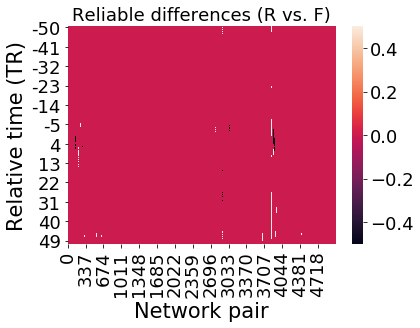

In [ ]:
sns.heatmap(pd.DataFrame(np.multiply(tvals, (pvals < 0.05/np.sum(np.isnan(pvals)))), index=np.arange(-buffer, buffer+1)), vmin=-0.5, vmax=0.5)
plt.title('Reliable differences (R vs. F)');
plt.ylabel('Relative time (TR)');
plt.xlabel('Network pair');

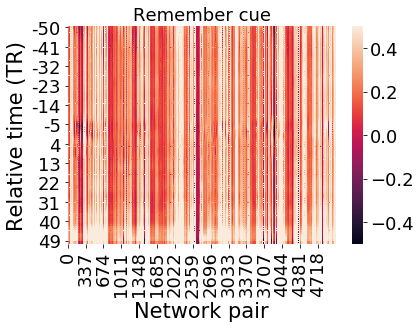

In [ ]:
sns.heatmap(pd.DataFrame(means[0], index=np.arange(-buffer, buffer+1)), vmin=-0.5, vmax=0.5)
plt.title('Remember cue');
plt.ylabel('Relative time (TR)');
plt.xlabel('Network pair');

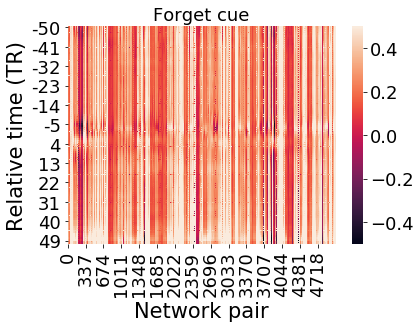

In [ ]:
sns.heatmap(pd.DataFrame(means[1], index=np.arange(-buffer, buffer+1)), vmin=-0.5, vmax=0.5)
plt.title('Forget cue');
plt.ylabel('Relative time (TR)');
plt.xlabel('Network pair');

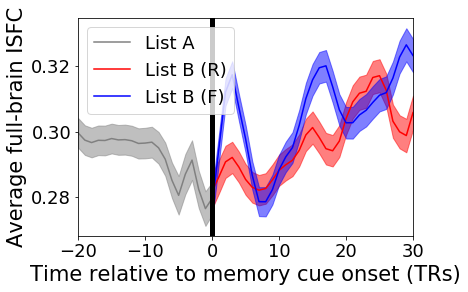

In [ ]:
ts = np.arange(-buffer, buffer+1)
min_time = -20
max_time = 30

colors = [[0.5, 0.5, 0.5], 'r', 'b']
event_ribbon(np.mean(np.concatenate([means[0][:, :, np.newaxis], means[1][:, :, np.newaxis]], axis=2), axis=2), ts=ts, color=colors[0], limit_t=[min_time, 0]);
event_ribbon(means[0], ts=ts, color=colors[1], limit_t=[0, max_time]);
event_ribbon(means[1], ts=ts, color=colors[2], limit_t=[0, max_time]);
plt.legend(['List A', 'List B (R)', 'List B (F)'])


plt.xlabel('Time relative to memory cue onset (TRs)')
plt.ylabel('Average full-brain ISFC')
plt.xlim([min_time, max_time]);
y = plt.ylim();
plt.plot([0, 0], y, 'k-', linewidth=5)
plt.ylim(y);
plt.savefig(os.path.join(figdir, 'ribbon_plot.pdf'))

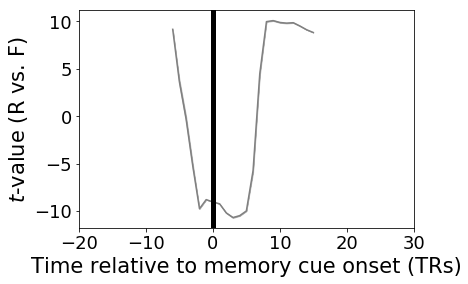

In [ ]:
nanned_filtered_tvals = filtered_tvals
nanned_filtered_tvals[nanned_filtered_tvals == 0] = np.nan
event_ribbon(filtered_tvals, ts=ts, color=[0.5, 0.5, 0.5], limit_t=[min_time, max_time])
plt.xlabel('Time relative to memory cue onset (TRs)')
plt.ylabel('$t$-value (R vs. F)')
plt.xlim([min_time, max_time]);
y = plt.ylim();
plt.plot([0, 0], y, 'k-', linewidth=5)
plt.ylim(y);
plt.savefig(os.path.join(figdir, 't_vals_timeseries.pdf'))

In [ ]:
eng = mlab.start_matlab()

In [ ]:
def mlab_array(x):    
    return matlab.double(x.tolist())

In [ ]:
def BrainNet_animation(centers, widths, connections, outfile, ts=None, limit_t=None, force_refresh=False):
    if ts is None:
        ts = np.arange(connections.shape[2])
    
    if not (limit_t is None):
        inds = (ts >= np.min(limit_t)) & (ts <= np.max(limit_t))
    else:
        inds = np.ones(ts.shape[0]) > 0
    
    ts = ts[inds]
    connections = connections[:, :, inds]
    
    for i, t in enumerate(ts):
        next_fname = outfile + '_' + '{:03d}'.format(i) + '.jpg'
        if (not os.path.exists(next_fname)) or force_refresh:
            eng.TFA_BrainNet_wrapper(mlab_array(centers), mlab_array(widths), mlab_array(np.squeeze(connections[:, :, i])), next_fname, os.path.join('data', 'brainnet_config_DF.mat'), nargout=0)
                                            

In [ ]:
BrainNet_animation(centers, widths, tc.vec2mat(filtered_tvals), ts=ts, limit_t=[min_time, max_time], outfile=os.path.join(figdir, 'diffs'), force_refresh=True)
BrainNet_animation(centers, widths, tc.vec2mat(means[0]), ts=ts, limit_t=[min_time, max_time], outfile=os.path.join(figdir, 'remember'), force_refresh=True)
BrainNet_animation(centers, widths, tc.vec2mat(means[1]), ts=ts, limit_t=[min_time, max_time], outfile=os.path.join(figdir, 'forget'), force_refresh=True)

In [ ]:
eng.exit()

In [ ]:
!ffmpeg -i {figdir}/diffs_%03d.jpg -c:v libx264 -r 25 {figdir}/diffs.mp4

ffmpeg version 4.0.2 Copyright (c) 2000-2018 the FFmpeg developers
  built with Apple LLVM version 9.1.0 (clang-902.0.39.2)
  configuration: --prefix=/usr/local/Cellar/ffmpeg/4.0.2 --enable-shared --enable-pthreads --enable-version3 --enable-hardcoded-tables --enable-avresample --cc=clang --host-cflags= --host-ldflags= --enable-gpl --enable-libmp3lame --enable-libx264 --enable-libxvid --enable-opencl --enable-videotoolbox --disable-lzma
  libavutil      56. 14.100 / 56. 14.100
  libavcodec     58. 18.100 / 58. 18.100
  libavformat    58. 12.100 / 58. 12.100
  libavdevice    58.  3.100 / 58.  3.100
  libavfilter     7. 16.100 /  7. 16.100
  libavresample   4.  0.  0 /  4.  0.  0
  libswscale      5.  1.100 /  5.  1.100
  libswresample   3.  1.100 /  3.  1.100
  libpostproc    55.  1.100 / 55.  1.100
Input #0, image2, from 'figs/gaussian/var10/Schaefer/100_parcels/diffs_%03d.jpg':
  Duration: 00:00:02.04, start: 0.000000, bitrate: N/A
    Stream #0:0: Video: mjpeg, yuvj420p(pc, bt470bg/u

In [ ]:
!ffmpeg -i {figdir}/remember_%03d.jpg -c:v libx264 -r 25 {figdir}/remember.mp4

ffmpeg version 4.0.2 Copyright (c) 2000-2018 the FFmpeg developers
  built with Apple LLVM version 9.1.0 (clang-902.0.39.2)
  configuration: --prefix=/usr/local/Cellar/ffmpeg/4.0.2 --enable-shared --enable-pthreads --enable-version3 --enable-hardcoded-tables --enable-avresample --cc=clang --host-cflags= --host-ldflags= --enable-gpl --enable-libmp3lame --enable-libx264 --enable-libxvid --enable-opencl --enable-videotoolbox --disable-lzma
  libavutil      56. 14.100 / 56. 14.100
  libavcodec     58. 18.100 / 58. 18.100
  libavformat    58. 12.100 / 58. 12.100
  libavdevice    58.  3.100 / 58.  3.100
  libavfilter     7. 16.100 /  7. 16.100
  libavresample   4.  0.  0 /  4.  0.  0
  libswscale      5.  1.100 /  5.  1.100
  libswresample   3.  1.100 /  3.  1.100
  libpostproc    55.  1.100 / 55.  1.100
Input #0, image2, from 'figs/gaussian/var10/Schaefer/100_parcels/remember_%03d.jpg':
  Duration: 00:00:02.04, start: 0.000000, bitrate: N/A
    Stream #0:0: Video: mjpeg, yuvj420p(pc, bt470b

In [ ]:
!ffmpeg -i {figdir}/forget_%03d.jpg -c:v libx264 -r 25 {figdir}/forget.mp4

ffmpeg version 4.0.2 Copyright (c) 2000-2018 the FFmpeg developers
  built with Apple LLVM version 9.1.0 (clang-902.0.39.2)
  configuration: --prefix=/usr/local/Cellar/ffmpeg/4.0.2 --enable-shared --enable-pthreads --enable-version3 --enable-hardcoded-tables --enable-avresample --cc=clang --host-cflags= --host-ldflags= --enable-gpl --enable-libmp3lame --enable-libx264 --enable-libxvid --enable-opencl --enable-videotoolbox --disable-lzma
  libavutil      56. 14.100 / 56. 14.100
  libavcodec     58. 18.100 / 58. 18.100
  libavformat    58. 12.100 / 58. 12.100
  libavdevice    58.  3.100 / 58.  3.100
  libavfilter     7. 16.100 /  7. 16.100
  libavresample   4.  0.  0 /  4.  0.  0
  libswscale      5.  1.100 /  5.  1.100
  libswresample   3.  1.100 /  3.  1.100
  libpostproc    55.  1.100 / 55.  1.100
Input #0, image2, from 'figs/gaussian/var10/Schaefer/100_parcels/forget_%03d.jpg':
  Duration: 00:00:02.04, start: 0.000000, bitrate: N/A
    Stream #0:0: Video: mjpeg, yuvj420p(pc, bt470bg/